# 🏈 SIDELINE DECISION SYSTEM
## NFL Big Data Bowl 2025: Coach-Ready Play-Calling Intelligence

---

**Purpose:** Transform data analysis into actionable sideline decisions

**For:** NFL Coaches, Offensive Coordinators, and Play-Callers

**Data Source:** NFL Big Data Bowl 2023 Season Tracking Data (Weeks 1-18)

---

In [9]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import Rectangle, Circle, Arc, FancyBboxPatch
import seaborn as sns
import warnings
import json
from pathlib import Path

# Interactive widgets
try:
    import ipywidgets as widgets
    from ipywidgets import interact, interactive, fixed, interact_manual
    from IPython.display import display, HTML, Markdown
    WIDGETS_AVAILABLE = True
except ImportError:
    print("⚠️ ipywidgets not available. Install with: pip install ipywidgets")
    WIDGETS_AVAILABLE = False

# Interactive plotting
try:
    import plotly.graph_objects as go
    import plotly.express as px
    from plotly.subplots import make_subplots
    PLOTLY_AVAILABLE = True
except ImportError:
    print("⚠️ plotly not available. Install with: pip install plotly")
    PLOTLY_AVAILABLE = False

warnings.filterwarnings('ignore')

# Set style for professional charts
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# NFL Color Palette
NFL_BLUE = '#013369'
NFL_RED = '#D50A0A'
NFL_GREEN = '#006400'
NFL_GOLD = '#FFB81C'
FIELD_GREEN = '#2D5016'

# Set default figure size
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12

print("✅ Libraries imported successfully")
print(f"✅ Interactive widgets available: {WIDGETS_AVAILABLE}")
print(f"✅ Plotly available: {PLOTLY_AVAILABLE}")

✅ Libraries imported successfully
✅ Interactive widgets available: True
✅ Plotly available: True


In [10]:
# Directory of this script: .../NFL-Big-Data-Bowl-2026-Analytics-Challenge
SCRIPT_DIR = Path('C:\\Users\\jrzem\\Downloads\\NFL-Big-Data-Bowl-2026-Analytics-Challenge\\notebooks\\08_Final_Sideline_Suggestions.ipynb').resolve().parent

# Project root = go up one level from analysis/
PROJECT_ROOT = SCRIPT_DIR.parent

# Data directories
data_dir = PROJECT_ROOT / "specific analysis" / "data"


# Load key datasets
decision_matrix = pd.read_csv(data_dir / 'decision_matrix_situation_vs_coverage.csv')
decision_matrix_epa = pd.read_csv(data_dir / 'decision_matrix_situation_vs_coverage_epa.csv')
play_action_impact = pd.read_csv(data_dir / 'play_action_impact_summary.csv')
formation_rankings = pd.read_csv(data_dir / 'formation_rankings_by_down_distance.csv')
pass_length_comparison = pd.read_csv(data_dir/ 'pass_length_comparison_by_situation.csv', skiprows=3, header=None)
coverage_heatmap = pd.read_csv(data_dir / 'coverage_heatmap_completion_rate.csv')

# Load QB-WR pair data
fourth_down_top10 = pd.read_csv(data_dir / 'fourth_down_top10.csv')
red_zone_top10 = pd.read_csv(data_dir / 'red_zone_top10.csv')
two_minute_top10 = pd.read_csv(data_dir / 'two-minute_drill_top10.csv')
third_long_top10 = pd.read_csv(data_dir / 'third_and_long_top10.csv')
goal_line_top10 = pd.read_csv(data_dir / 'goal_line_top10.csv')
clutch_pairs = pd.read_csv(data_dir / 'clutch_qb_wr_pairs.csv')

# Load additional analysis data
route_effectiveness = pd.read_csv(data_dir / 'route_effectiveness_by_field_position.csv')
formation_success = pd.read_csv(data_dir / 'formation_success_by_down_distance.csv')
coverage_by_situation = pd.read_csv(data_dir / 'coverage_type_success_by_situation.csv')
separation_analysis = pd.read_csv(data_dir / 'separation_analysis.csv')

print("✅ All datasets loaded successfully")
print(f"\n📊 Data Summary:")
print(f"  - Decision Matrix: {decision_matrix.shape}")
print(f"  - Play Action Impact: {play_action_impact.shape}")
print(f"  - Formation Rankings: {formation_rankings.shape}")
print(f"  - Separation Analysis: {separation_analysis.shape[0]:,} plays analyzed")

✅ All datasets loaded successfully

📊 Data Summary:
  - Decision Matrix: (5, 9)
  - Play Action Impact: (5, 7)
  - Formation Rankings: (28, 6)
  - Separation Analysis: 997 plays analyzed


---

# 📋 SECTION 1: EXECUTIVE SUMMARY
## Game Plan: Your Data-Driven Coaching Toolkit

---

### 🎯 TOP 7 COACHING TAKEAWAYS

#### **1. EXPLOIT COVER 2 ZONE RELENTLESSLY**
- **61-76% completion rate** across all pressure situations
- Most vulnerable coverage type in the NFL
- **Action:** Make Cover 2 your primary target in 4th down, red zone, and 2-minute drill

#### **2. PLAY ACTION ON 4TH DOWN = GAME CHANGER**
- **+14.9% completion rate** improvement (71.4% vs 56.5%)
- **+0.840 EPA boost** - nearly a full point of expected value
- **Action:** Use play action on 75%+ of 4th down attempts when defense expects run

#### **3. TRUST YOUR ELITE QB-WR CHEMISTRY IN PRESSURE**
- Multiple pairs with **100% completion rates** in critical situations
- Example: T.Tagovailoa → J.Waddle (3/3 on 4th down, 10.36 EPA)
- **Action:** Lean on proven pairs in clutch moments - chemistry beats coverage

#### **4. EMPTY FORMATION ON 3RD & LONG**
- **0.379 EPA** - highest success rate for long-yardage conversions
- Forces defense into predictable coverages
- **Action:** Go empty on 3rd & 10+ to create mismatches and clear throwing lanes

#### **5. SEPARATION MATTERS - BUT NOT AS MUCH AS YOU THINK**
- Only **0.37 yards difference** between completions (4.20 yds) and incompletions (3.83 yds)
- QB decision-making and timing trump pure separation
- **Action:** Don't wait for receivers to be "wide open" - trust rhythm and anticipation

#### **6. SHORT PASSES = HIGH COMPLETION, LOW REWARD**
- 0-5 yards: **75-82% completion** but lowest EPA
- 16+ yards: **30-48% completion** but highest EPA when it hits
- **Action:** Mix depths strategically - use short to move chains, deep to move scoreboard

#### **7. TWO-MINUTE DRILL: SIDELINE ROUTES WITH PLAY ACTION**
- Play action still effective: **+4.4% completion, +0.071 EPA**
- Sideline routes stop clock AND gain yards
- **Action:** Don't abandon play action in hurry-up - defense still respects it

---

### 📖 WHAT YOU'LL FIND IN THIS NOTEBOOK

| Section | What's Inside | How to Use It |
|---------|--------------|---------------|
| **Section 2: Static Visualizations** | High-resolution charts and field diagrams for print or tablet | Print for laminated play-calling sheets or load on tablet |
| **Section 3: QB-WR Chemistry** | Top performer rankings by situation with bubble charts | Identify which pairs to feature in game plan |
| **Section 4: Interactive Tools** | Live decision engine with dropdowns and sliders | Run during practice week to simulate game situations |
| **Section 5: Coaching Applications** | Printable cheat sheets and risk/reward frameworks | Keep in play-calling card for in-game reference |

---

In [11]:
# Quick Stats Dashboard
print("" + "="*70)
print("          🏈 QUICK REFERENCE STATISTICS 🏈")
print("="*70)
print()
print("BEST COVERAGE TO ATTACK:")
print("  Cover 2 Zone - 74.6% completion (Red Zone)")
print("  Cover 2 Zone - 73.6% completion (3rd & Long)")
print("  Cover 2 Zone - 61.1% completion (4th Down)")
print()
print("PLAY ACTION ADVANTAGE:")
print("  4th Down:        +14.9% completion, +0.840 EPA")
print("  Red Zone:        +6.3% completion, +0.192 EPA")
print("  Two-Minute Drill: +4.4% completion, +0.071 EPA")
print()
print("TOP FORMATION BY SITUATION:")
print("  3rd & Long:  EMPTY (0.379 EPA)")
print("  3rd & Short: JUMBO (0.268 EPA)")
print("  Red Zone:    SHOTGUN (0.385 EPA with PA)")
print()
print("ELITE QB-WR PAIRS (100% Completion):")
print("  4th Down: T.Tagovailoa → J.Waddle (3/3, 10.36 EPA)")
print("  4th Down: J.Goff → J.Gibbs (3/3, 9.95 EPA)")
print("  4th Down: A.O'Connell → D.Adams (3/3, 9.61 EPA)")
print()
print("="*70)

          🏈 QUICK REFERENCE STATISTICS 🏈

BEST COVERAGE TO ATTACK:
  Cover 2 Zone - 74.6% completion (Red Zone)
  Cover 2 Zone - 73.6% completion (3rd & Long)
  Cover 2 Zone - 61.1% completion (4th Down)

PLAY ACTION ADVANTAGE:
  4th Down:        +14.9% completion, +0.840 EPA
  Red Zone:        +6.3% completion, +0.192 EPA
  Two-Minute Drill: +4.4% completion, +0.071 EPA

TOP FORMATION BY SITUATION:
  3rd & Long:  EMPTY (0.379 EPA)
  3rd & Short: JUMBO (0.268 EPA)
  Red Zone:    SHOTGUN (0.385 EPA with PA)

ELITE QB-WR PAIRS (100% Completion):
  4th Down: T.Tagovailoa → J.Waddle (3/3, 10.36 EPA)
  4th Down: J.Goff → J.Gibbs (3/3, 9.95 EPA)
  4th Down: A.O'Connell → D.Adams (3/3, 9.61 EPA)



---

# 📊 SECTION 2: STATIC VISUALIZATIONS (PAPER-READY)
## Publication-Quality Charts for Print and Presentation

---

In [12]:
# Helper function to create performance color map
def get_performance_color(value, metric='completion_rate'):
    """Return color based on performance thresholds"""
    if pd.isna(value):
        return '#CCCCCC'  # Gray for missing data
    
    if metric == 'completion_rate':
        if value >= 70:
            return '#006400'  # Dark green - excellent
        elif value >= 65:
            return '#90EE90'  # Light green - good
        elif value >= 60:
            return '#FFFF00'  # Yellow - average
        elif value >= 55:
            return '#FFA500'  # Orange - below average
        else:
            return '#FF0000'  # Red - poor
    elif metric == 'epa':
        if value >= 0.3:
            return '#006400'
        elif value >= 0.15:
            return '#90EE90'
        elif value >= 0.0:
            return '#FFFF00'
        elif value >= -0.1:
            return '#FFA500'
        else:
            return '#FF0000'

### 2.1 Decision Matrix: Coverage Vulnerability Heatmap

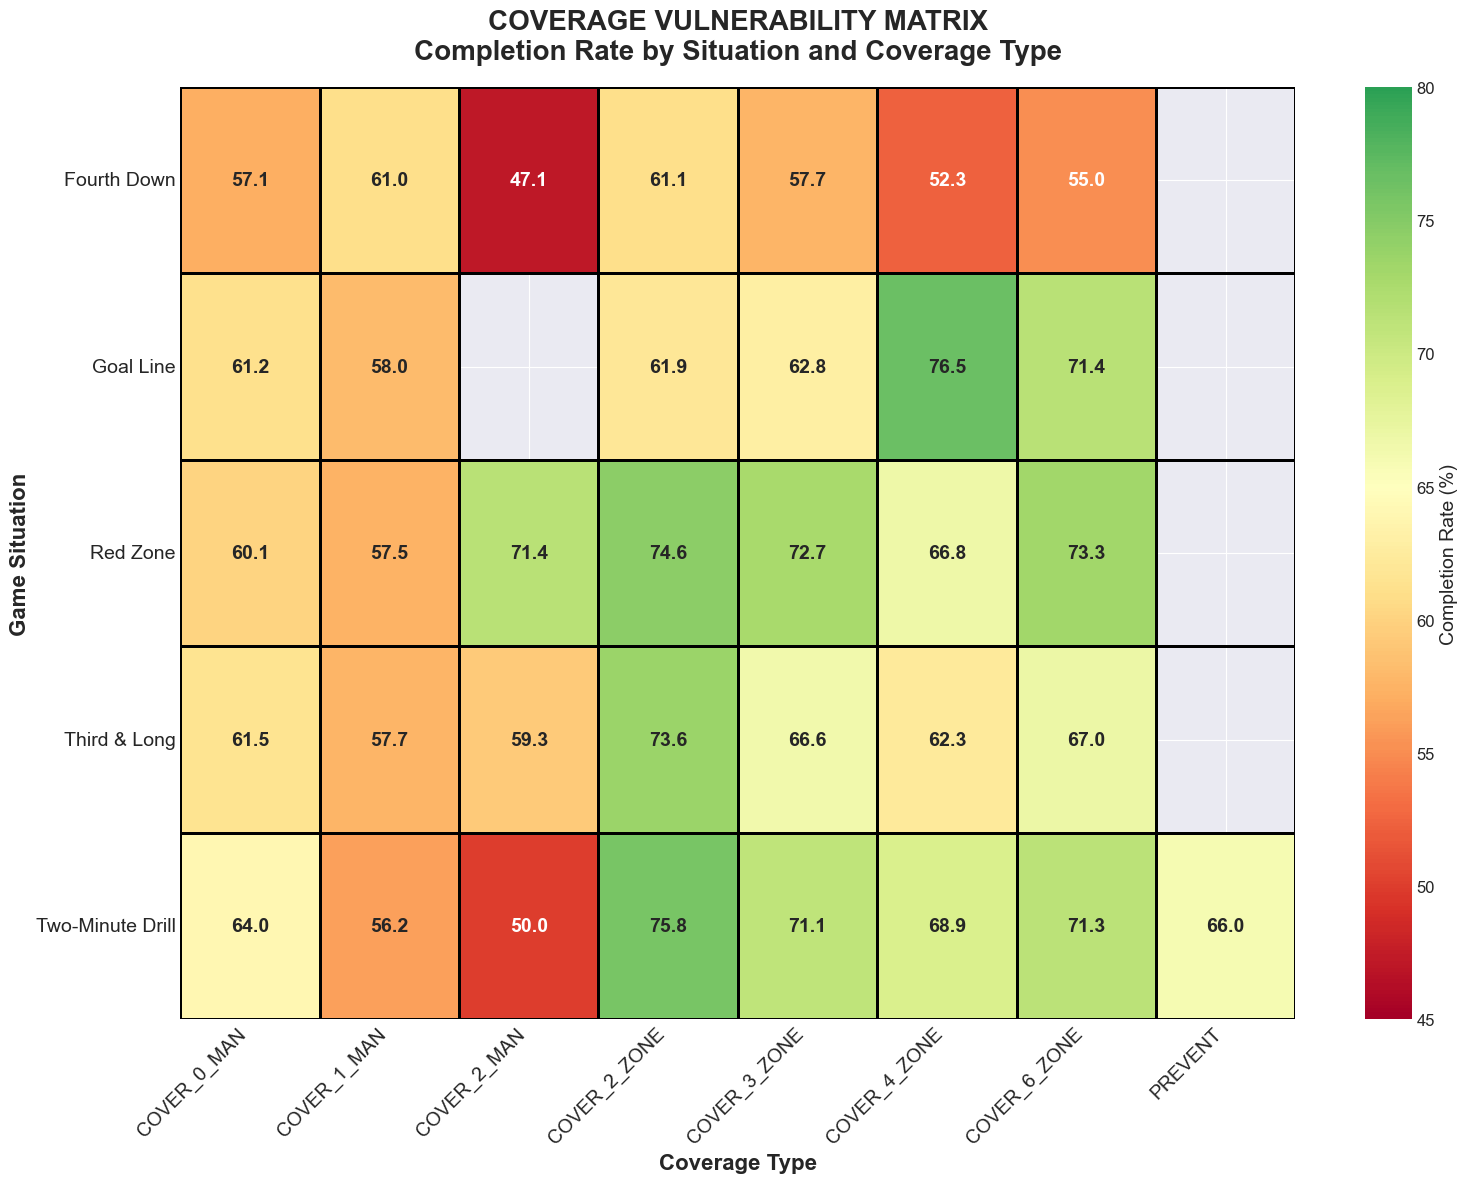

✅ Coverage Vulnerability Matrix saved


In [13]:
# Decision Matrix Heatmap - Completion Rate
fig, ax = plt.subplots(figsize=(16, 12))

# Prepare data for heatmap
matrix_data = decision_matrix.set_index('situation')
matrix_data = matrix_data.apply(pd.to_numeric, errors='coerce')

# Create heatmap
sns.heatmap(matrix_data, annot=True, fmt='.1f', cmap='RdYlGn', 
            center=65, vmin=45, vmax=80, 
            linewidths=2, linecolor='black',
            cbar_kws={'label': 'Completion Rate (%)'},
            ax=ax, annot_kws={'size': 14, 'weight': 'bold'})

ax.set_title('COVERAGE VULNERABILITY MATRIX\nCompletion Rate by Situation and Coverage Type', 
             fontsize=20, fontweight='bold', pad=20)
ax.set_xlabel('Coverage Type', fontsize=16, fontweight='bold')
ax.set_ylabel('Game Situation', fontsize=16, fontweight='bold')

# Rotate labels
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=14)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=14)


plt.tight_layout()
plt.savefig(SCRIPT_DIR/ 'Final Analysis/viz_coverage_vulnerability_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Coverage Vulnerability Matrix saved")

### 2.2 Play Action Advantage Chart

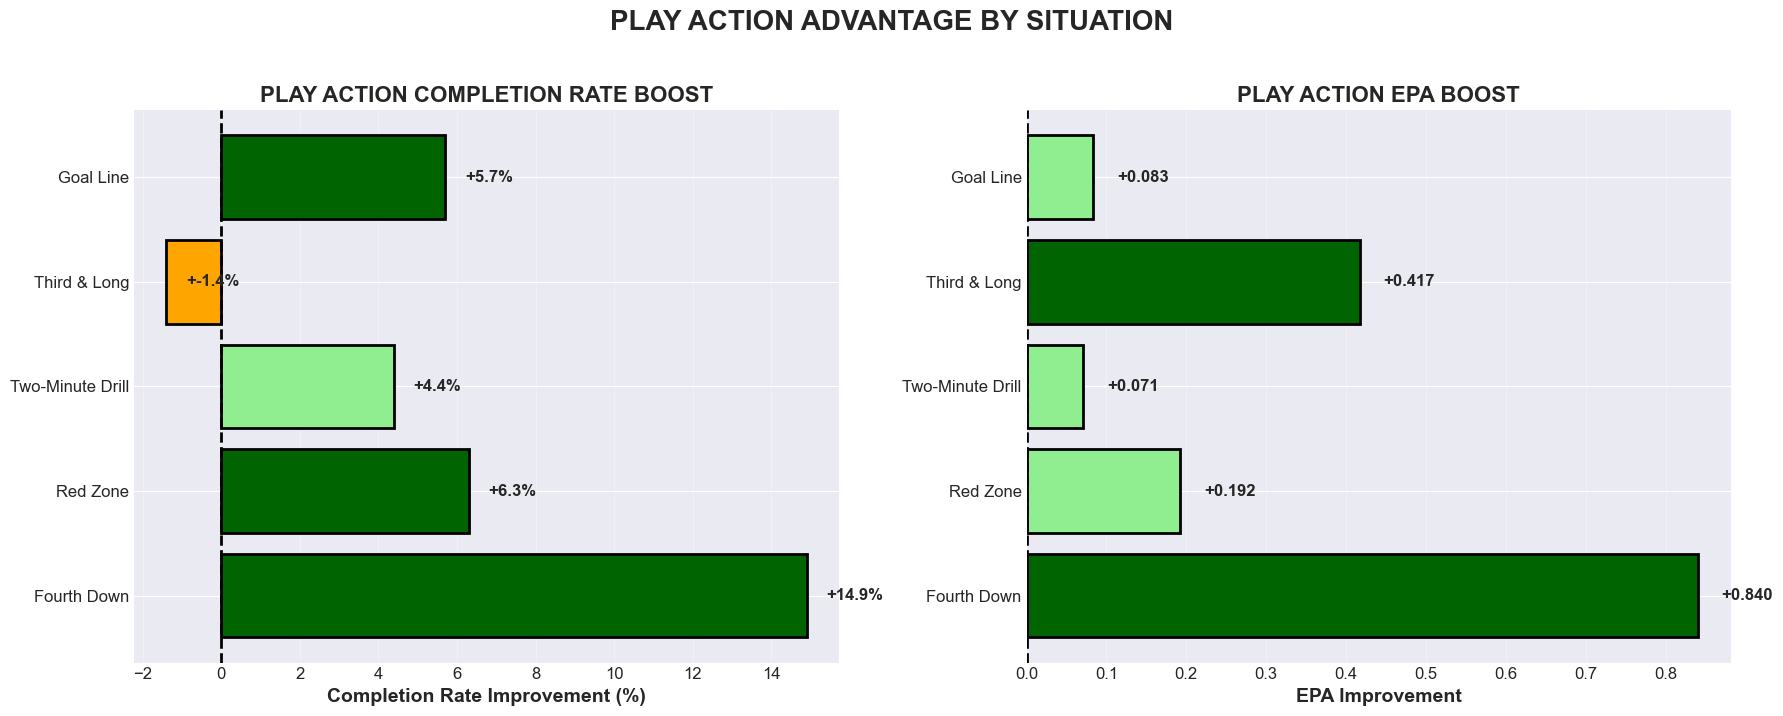

✅ Play Action Advantage chart saved


In [14]:
# Play Action Advantage Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Chart 1: Completion Rate Improvement
situations = play_action_impact['situation'].values
comp_improvement = play_action_impact['comp_rate_improvement'].values

colors = ['#006400' if x > 5 else '#90EE90' if x > 0 else '#FFA500' for x in comp_improvement]

bars1 = ax1.barh(situations, comp_improvement, color=colors, edgecolor='black', linewidth=2)
ax1.set_xlabel('Completion Rate Improvement (%)', fontsize=14, fontweight='bold')
ax1.set_title('PLAY ACTION COMPLETION RATE BOOST', fontsize=16, fontweight='bold')
ax1.axvline(x=0, color='black', linestyle='--', linewidth=2)
ax1.grid(axis='x', alpha=0.3)

# Add value labels
for i, (bar, val) in enumerate(zip(bars1, comp_improvement)):
    ax1.text(val + 0.5, i, f'+{val:.1f}%', va='center', fontsize=12, fontweight='bold')

# Chart 2: EPA Improvement
epa_improvement = play_action_impact['epa_improvement'].values
colors2 = ['#006400' if x > 0.3 else '#90EE90' if x > 0 else '#FFA500' for x in epa_improvement]

bars2 = ax2.barh(situations, epa_improvement, color=colors2, edgecolor='black', linewidth=2)
ax2.set_xlabel('EPA Improvement', fontsize=14, fontweight='bold')
ax2.set_title('PLAY ACTION EPA BOOST', fontsize=16, fontweight='bold')
ax2.axvline(x=0, color='black', linestyle='--', linewidth=2)
ax2.grid(axis='x', alpha=0.3)

# Add value labels
for i, (bar, val) in enumerate(zip(bars2, epa_improvement)):
    ax2.text(val + 0.03, i, f'+{val:.3f}', va='center', fontsize=12, fontweight='bold')

fig.suptitle('PLAY ACTION ADVANTAGE BY SITUATION', fontsize=20, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig(SCRIPT_DIR/ 'Final Analysis/viz_play_action_advantage.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Play Action Advantage chart saved")

### 2.3 NFL Field Diagram: Optimal Target Zones

✅ Loaded data from CSV


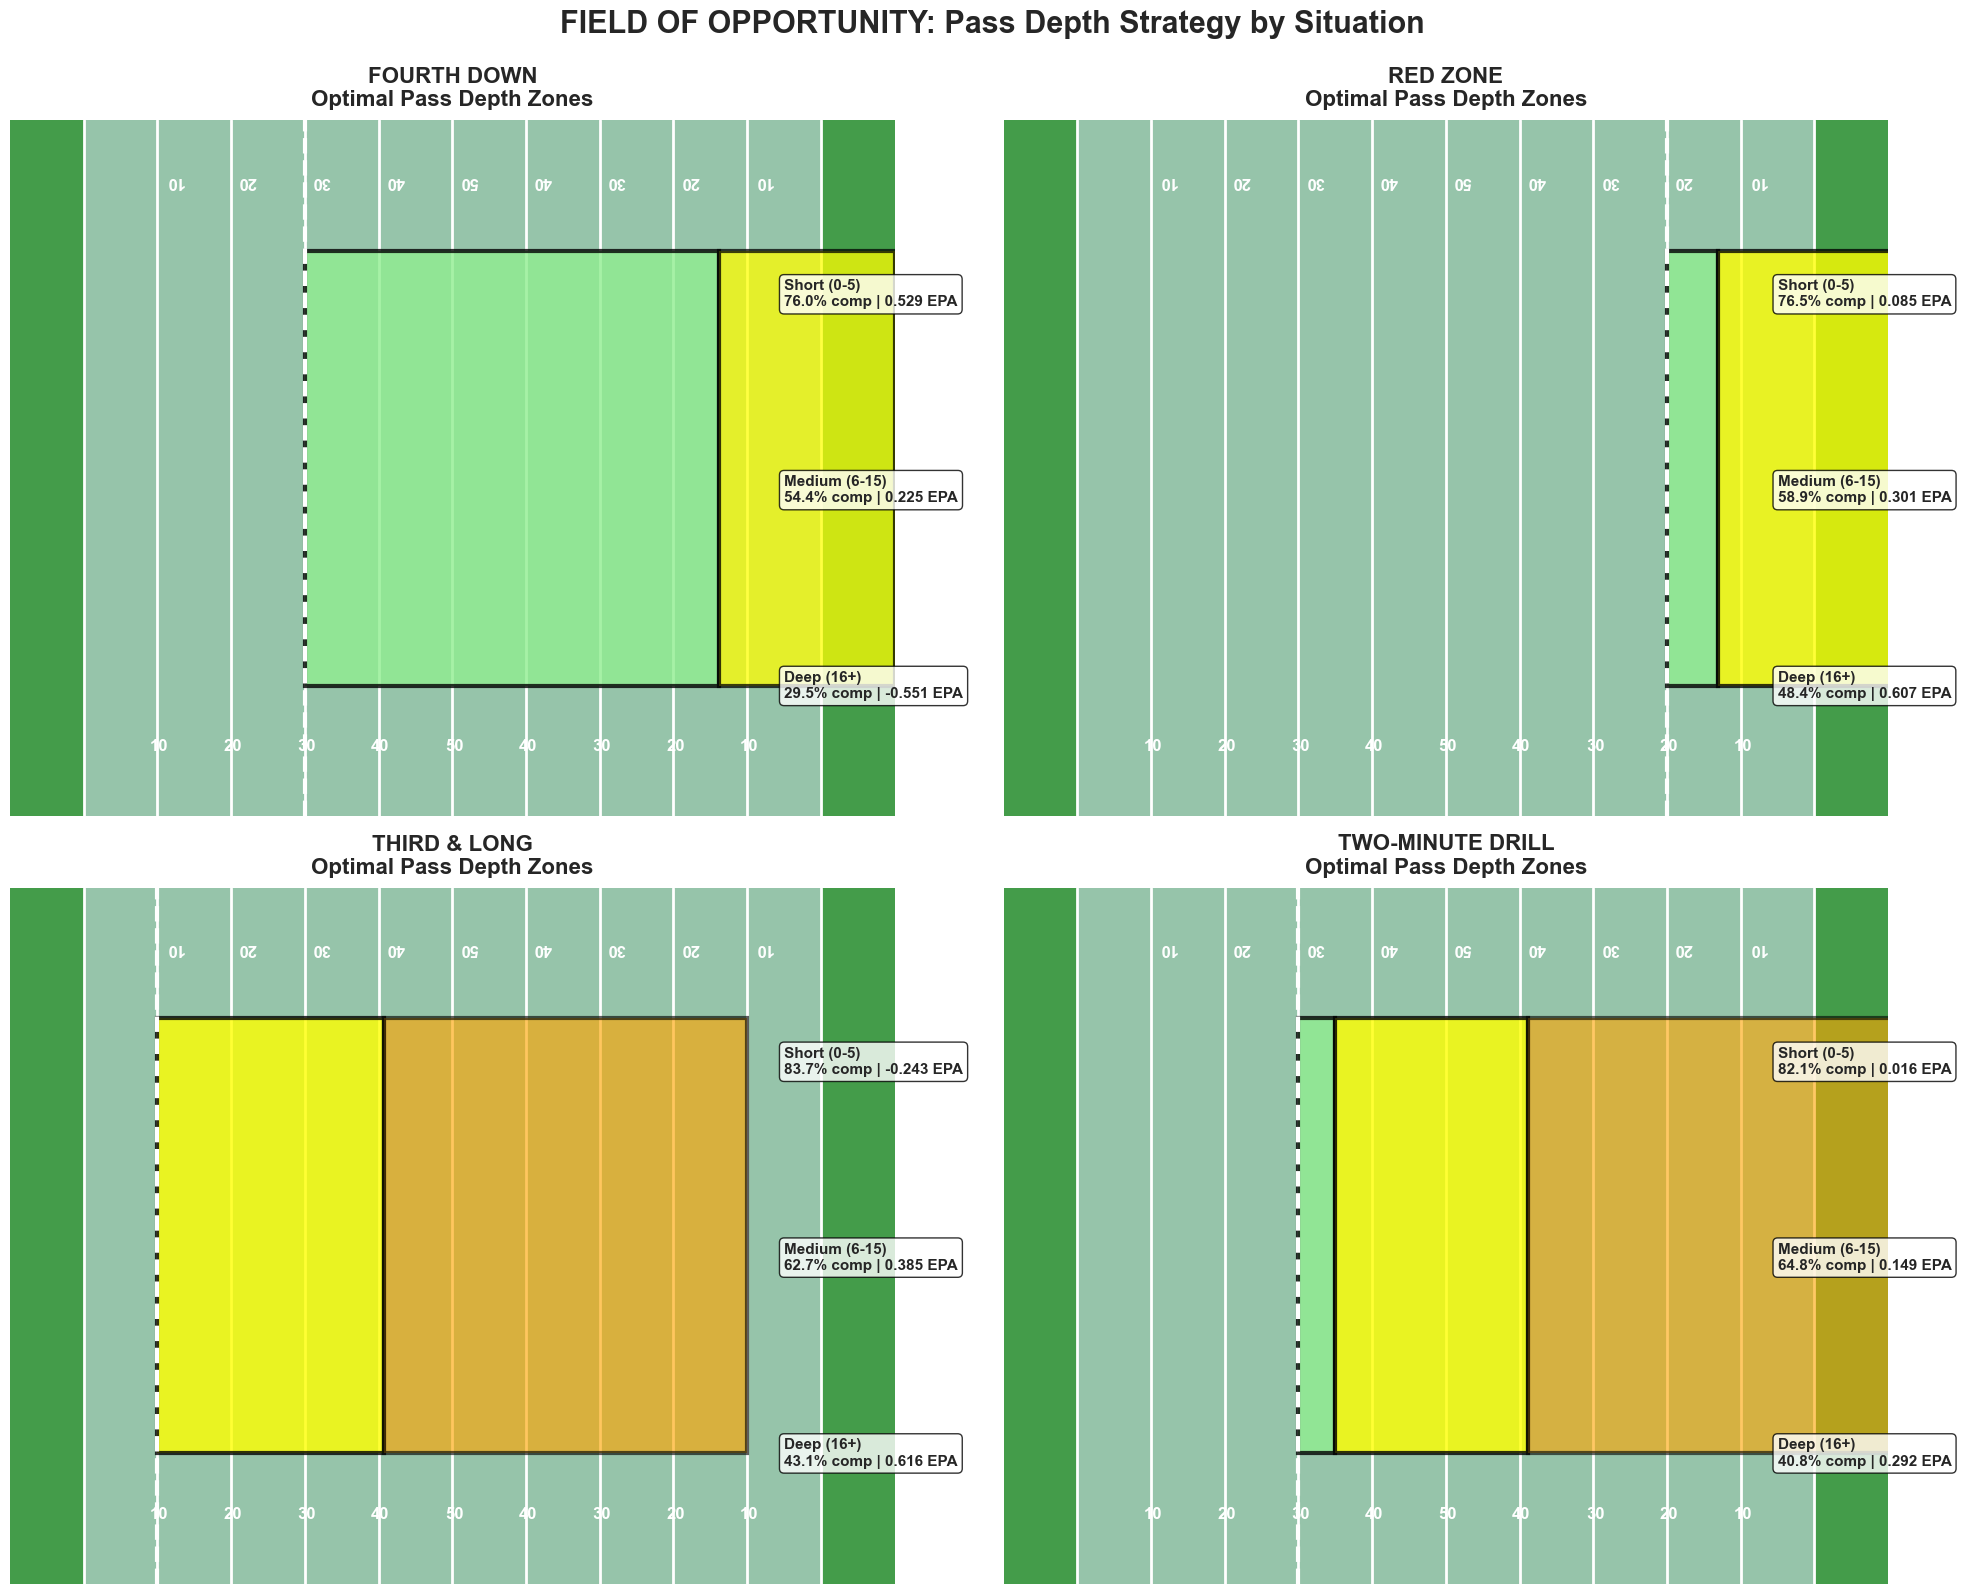

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import numpy as np

# 1. Load and Clean Data
# We skip the first 3 rows of metadata/headers and name columns manually 
# to match the structure expected by the plotting code.
# The structure is: Situation, Deep EPA, Med EPA, Short EPA, Deep Comp, Med Comp, Short Comp
try:
    pass_length_comparison = pd.read_csv(
        data_dir/ 'pass_length_comparison_by_situation.csv', 
        skiprows=3, 
        header=None,
        names=['situation', 'deep_epa', 'medium_epa', 'short_epa', 
               'deep_comp_rate', 'medium_comp_rate', 'short_comp_rate']
    )
    print("✅ Loaded data from CSV")
except FileNotFoundError:
    print("⚠️ CSV not found")

# 2. Define draw_nfl_field helper
def draw_nfl_field(ax, show_numbers=True):
    # Set field dimensions
    ax.set_xlim(0, 120)
    ax.set_ylim(0, 53.33)
    
    # Field background
    ax.add_patch(Rectangle((0, 0), 120, 53.33, facecolor='#2E8B57', alpha=0.5, zorder=0))
    
    # Endzones
    ax.add_patch(Rectangle((0, 0), 10, 53.33, facecolor='#228B22', alpha=0.7, zorder=1))
    ax.add_patch(Rectangle((110, 0), 10, 53.33, facecolor='#228B22', alpha=0.7, zorder=1))
    
    # Yard lines
    for i in range(10, 111, 10):
        ax.plot([i, i], [0, 53.33], color='white', linewidth=2, zorder=1)
        
    # Numbers (Simplified)
    if show_numbers:
        for i in range(20, 110, 10):
            yard_number = 50 - abs(i - 60)
            ax.text(i - 1, 5, str(yard_number), color='white', fontsize=12, fontweight='bold', zorder=2)
            ax.text(i + 1, 53.33 - 5, str(yard_number), color='white', fontsize=12, fontweight='bold', zorder=2, rotation=180)

    ax.axis('off')

# 3. Main Plotting Logic
fig, axes = plt.subplots(2, 2, figsize=(20, 16))
situations = ['Fourth Down', 'Red Zone', 'Third & Long', 'Two-Minute Drill']

# Depth order and colors (fixed)
depths = ['Short (0-5)', 'Medium (6-15)', 'Deep (16+)']
colors = {'Short (0-5)': '#90EE90', 'Medium (6-15)': '#FFFF00', 'Deep (16+)': '#FFA500'}

# Situation-specific starting points
start_positions = {
    'Fourth Down': 40,   
    'Red Zone': 90,      
    'Third & Long': 20,  
    'Two-Minute Drill': 40  
}

# Define vertical positions for labels
label_y_positions = {
    'Short (0-5)': 40,
    'Medium (6-15)': 25,
    'Deep (16+)': 10
}

for idx, (ax, situation) in enumerate(zip(axes.flat, situations)):
    draw_nfl_field(ax, show_numbers=True)
    
    # Get data for this situation
    sit_data = pass_length_comparison[pass_length_comparison['situation'] == situation]
    
    if not sit_data.empty:
        # Extract values
        epa_values = {
            'Short (0-5)': sit_data['short_epa'].values[0],
            'Medium (6-15)': sit_data['medium_epa'].values[0],
            'Deep (16+)': sit_data['deep_epa'].values[0]
        }
        comp_values = {
            'Short (0-5)': sit_data['short_comp_rate'].values[0],
            'Medium (6-15)': sit_data['medium_comp_rate'].values[0],
            'Deep (16+)': sit_data['deep_comp_rate'].values[0]
        }
        
        # Compute scores: max(EPA, 0) for positive opportunity only
        scores = [max(epa_values[depth], 0) for depth in depths]
        total_score = sum(scores)
        total_width = 80  # Total zone span
        
        # Normalize widths
        widths = []
        for score in scores:
            if score > 0:
                # Ensure minimum visibility (5 yards) if there is any positive score
                val = (score / total_score * total_width) if total_score > 0 else 0
                widths.append(max(5, val))
            else:
                widths.append(0)
        
        # Draw zones
        current_start = start_positions[situation]
        for i, depth in enumerate(depths):
            if widths[i] > 0:
                alpha = min(comp_values[depth] / 100 + 0.2, 0.8)
                rect = Rectangle((current_start, 10), widths[i], 33.33,
                                 facecolor=colors[depth], alpha=alpha,
                                 edgecolor='black', linewidth=3)
                ax.add_patch(rect)
                current_start += widths[i]
        
        # Line of scrimmage
        ax.plot([start_positions[situation], start_positions[situation]], [0, 53.33], 
                'white', linewidth=3, linestyle='--')
        
        # Labels
        for depth in depths:
            label = f"{depth}\n{comp_values[depth]:.1f}% comp | {epa_values[depth]:.3f} EPA"
            ax.text(105, label_y_positions[depth], label,
                    ha='left', va='center', fontsize=11, fontweight='bold',
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    ax.set_title(f'{situation.upper()}\nOptimal Pass Depth Zones', 
                 fontsize=16, fontweight='bold', pad=10)

fig.suptitle('FIELD OF OPPORTUNITY: Pass Depth Strategy by Situation', 
             fontsize=22, fontweight='bold', y=0.995)

plt.tight_layout()
plt.savefig(SCRIPT_DIR / 'Final Analysis/viz_field_of_opportunity.png', dpi=300, bbox_inches='tight')
plt.show()

### 2.4 Formation Success Rankings

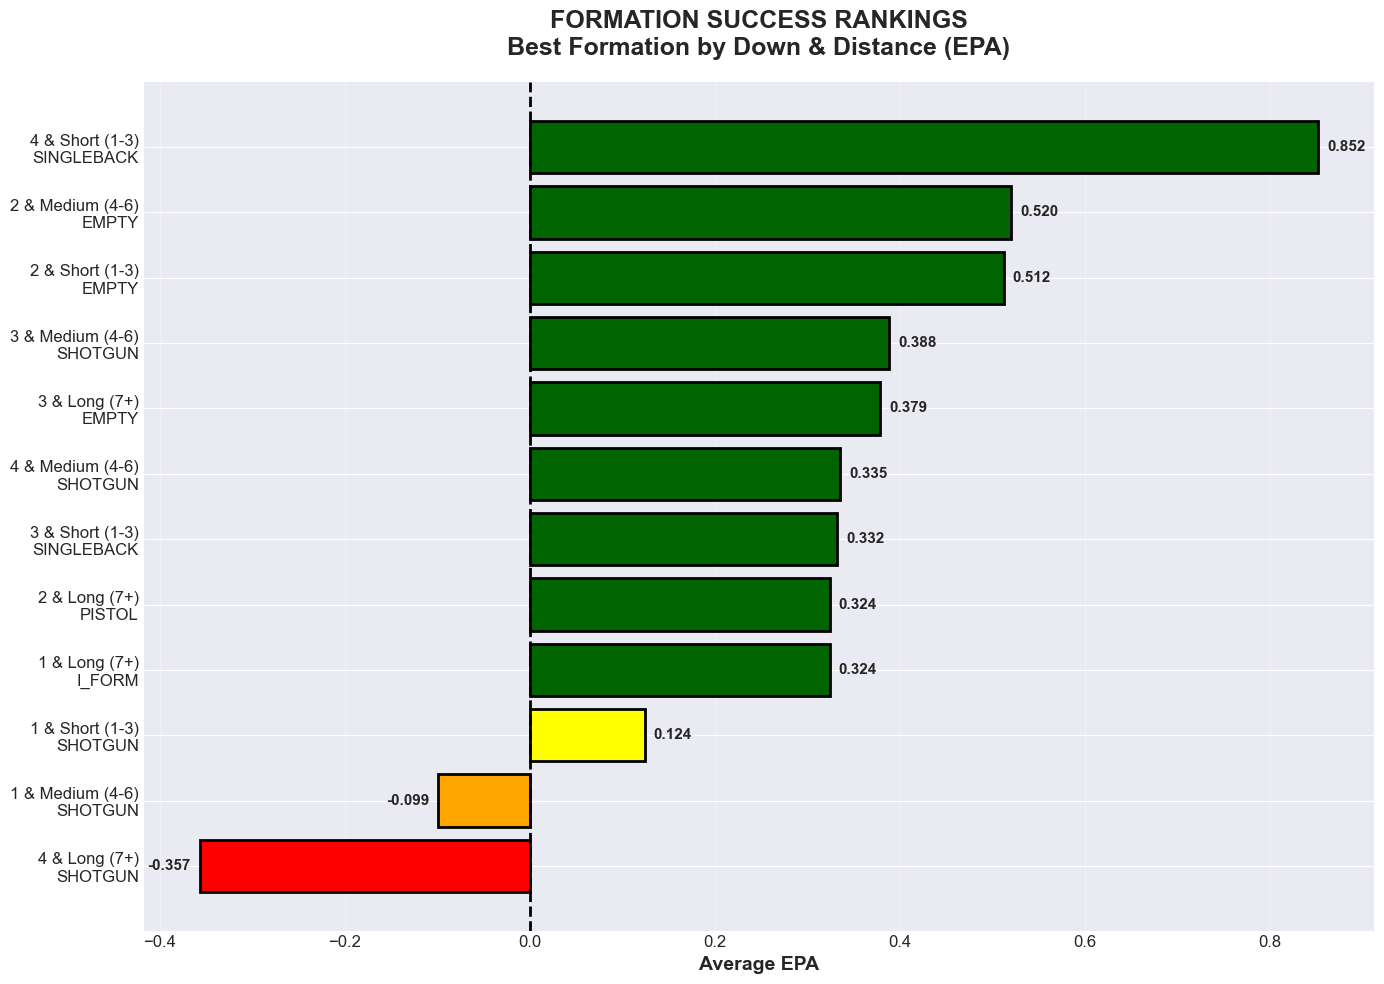

✅ Formation Success Rankings saved


In [16]:
# Formation Success by Down/Distance
fig, ax = plt.subplots(figsize=(14, 10))

# Prepare data
if 'down_distance' in formation_rankings.columns and 'formation' in formation_rankings.columns:
    plot_data = formation_rankings[formation_rankings['rank'] == 1].copy()
    plot_data = plot_data.sort_values('avg_epa', ascending=True)
    
    # Create horizontal bar chart
    colors = [get_performance_color(epa, 'epa') for epa in plot_data['avg_epa']]
    
    bars = ax.barh(range(len(plot_data)), plot_data['avg_epa'], 
                   color=colors, edgecolor='black', linewidth=2)
    
    # Set y-tick labels
    labels = [f"{row['down_distance']}\n{row['formation']}" 
             for _, row in plot_data.iterrows()]
    ax.set_yticks(range(len(plot_data)))
    ax.set_yticklabels(labels, fontsize=12)
    
    # Add value labels
    for i, (bar, val) in enumerate(zip(bars, plot_data['avg_epa'])):
        x_pos = val + 0.01 if val >= 0 else val - 0.01
        ha = 'left' if val >= 0 else 'right'
        ax.text(x_pos, i, f'{val:.3f}', va='center', ha=ha, 
               fontsize=11, fontweight='bold')
    
    ax.axvline(x=0, color='black', linestyle='--', linewidth=2)
    ax.set_xlabel('Average EPA', fontsize=14, fontweight='bold')
    ax.set_title('FORMATION SUCCESS RANKINGS\nBest Formation by Down & Distance (EPA)', 
                fontsize=18, fontweight='bold', pad=20)
    ax.grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(SCRIPT_DIR / 'Final Analysis/viz_formation_success_rankings.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✅ Formation Success Rankings saved")
else:
    print("⚠️ Formation rankings data structure different than expected")
    print(f"Columns available: {formation_rankings.columns.tolist()}")

### 2.5 Pass Depth Strategy: Completion Rate vs EPA Trade-off

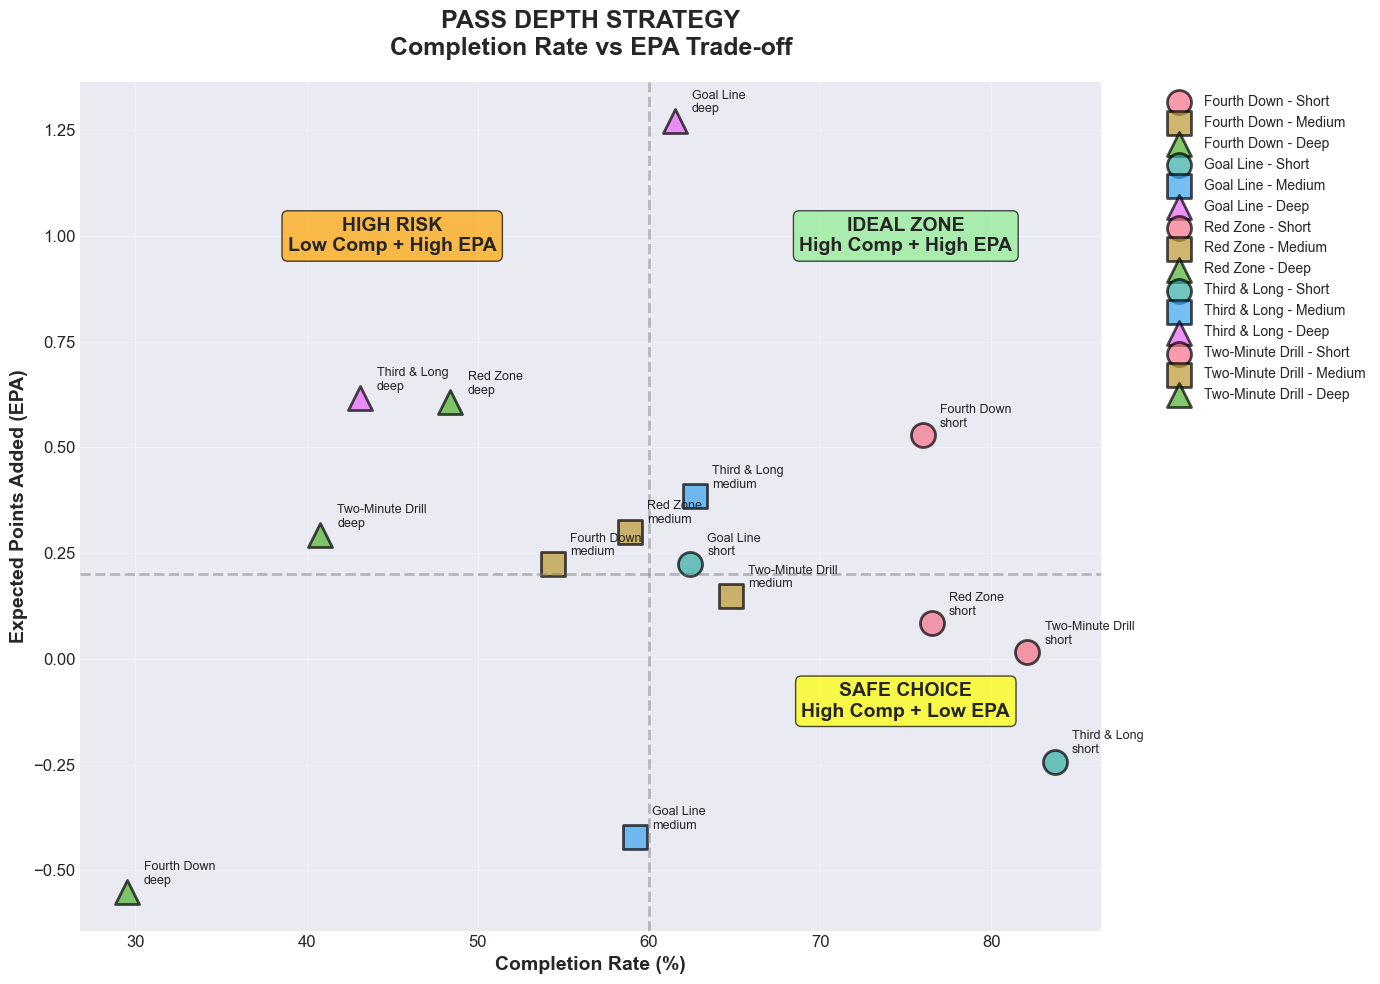

✅ Pass Depth Strategy chart saved


In [17]:
# Pass Depth Strategy Scatter Plot
fig, ax = plt.subplots(figsize=(14, 10))

# Prepare data from pass_length_comparison
if not pass_length_comparison.empty:
    situations = pass_length_comparison['situation'].unique()
    
    # Define pass depth categories and their typical stats
    depth_categories = ['short', 'medium', 'deep']
    markers = {'short': 'o', 'medium': 's', 'deep': '^'}
    
    for situation in situations:
        sit_data = pass_length_comparison[pass_length_comparison['situation'] == situation]
        
        for depth in depth_categories:
            comp_col = f'{depth}_comp_rate'
            epa_col = f'{depth}_epa'
            
            if comp_col in sit_data.columns and epa_col in sit_data.columns:
                comp_rate = sit_data[comp_col].values[0]
                epa = sit_data[epa_col].values[0]
                
                if not pd.isna(comp_rate) and not pd.isna(epa):
                    ax.scatter(comp_rate, epa, s=300, marker=markers[depth],
                             label=f'{situation} - {depth.capitalize()}',
                             alpha=0.7, edgecolors='black', linewidth=2)
                    
                    # Add text label
                    ax.text(comp_rate + 1, epa + 0.02, 
                           f'{situation}\n{depth}',
                           fontsize=9, ha='left')
    
    # Add quadrant lines
    ax.axhline(y=0.2, color='gray', linestyle='--', linewidth=2, alpha=0.5)
    ax.axvline(x=60, color='gray', linestyle='--', linewidth=2, alpha=0.5)
    
    # Add quadrant labels
    ax.text(75, 1, 'IDEAL ZONE\nHigh Comp + High EPA', 
           ha='center', va='center', fontsize=14, fontweight='bold',
           bbox=dict(boxstyle='round', facecolor='#90EE90', alpha=0.7))
    
    ax.text(45, 1, 'HIGH RISK\nLow Comp + High EPA', 
           ha='center', va='center', fontsize=14, fontweight='bold',
           bbox=dict(boxstyle='round', facecolor='#FFA500', alpha=0.7))
    
    ax.text(75, -0.1, 'SAFE CHOICE\nHigh Comp + Low EPA', 
           ha='center', va='center', fontsize=14, fontweight='bold',
           bbox=dict(boxstyle='round', facecolor='#FFFF00', alpha=0.7))
    
    ax.set_xlabel('Completion Rate (%)', fontsize=14, fontweight='bold')
    ax.set_ylabel('Expected Points Added (EPA)', fontsize=14, fontweight='bold')
    ax.set_title('PASS DEPTH STRATEGY\nCompletion Rate vs EPA Trade-off', 
                fontsize=18, fontweight='bold', pad=20)
    ax.grid(alpha=0.3)
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
    
    plt.tight_layout()
    plt.savefig(SCRIPT_DIR / 'Final Analysis/viz_pass_depth_strategy.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✅ Pass Depth Strategy chart saved")
else:
    print("⚠️ Pass length comparison data not available")

---

# 👥 SECTION 3: QB-WR CHEMISTRY ANALYSIS
## Elite Performers in Pressure Situations

---

### 3.1 Top 10 QB-WR Pairs by Critical Situation

In [18]:
# Display Top 10 QB-WR Pairs for Each Situation
situations_data = {
    'Fourth Down': fourth_down_top10,
    'Red Zone': red_zone_top10,
    'Two-Minute Drill': two_minute_top10,
    'Third & Long': third_long_top10,
    'Goal Line': goal_line_top10
}

for situation_name, df in situations_data.items():
    print("\n" + "="*80)
    print(f"🏆 TOP 10 QB-WR PAIRS: {situation_name.upper()}")
    print("="*80)
    
    if not df.empty:
        display_df = df[['qb_wr_pair', 'targets', 'completions', 'completion_rate', 
                        'total_epa', 'avg_epa']].head(10).copy()
        display_df['completion_rate'] = display_df['completion_rate'].apply(lambda x: f"{x:.1f}%")
        display_df['total_epa'] = display_df['total_epa'].apply(lambda x: f"{x:.2f}")
        display_df['avg_epa'] = display_df['avg_epa'].apply(lambda x: f"{x:.3f}")
        
        print(display_df.to_string(index=False))
    else:
        print("No data available")
    print()


🏆 TOP 10 QB-WR PAIRS: FOURTH DOWN
             qb_wr_pair  targets  completions completion_rate total_epa avg_epa
T.Tagovailoa → J.Waddle        3            3          100.0%     10.36   3.453
       J.Goff → J.Gibbs        3            3          100.0%      9.95   3.315
    J.Flacco → A.Cooper        3            3          100.0%      9.81   3.272
  A.O'Connell → D.Adams        3            3          100.0%      9.61   3.205
  S.Howell → B.Robinson        3            3          100.0%      9.08   3.028
D.Prescott → J.Ferguson        3            3          100.0%      7.78   2.594
   Z.Wilson → T.Conklin        4            4          100.0%     -3.31  -0.828
    B.Young → A.Thielen       11            9           81.8%     15.43   1.403
    B.Young → T.Tremble        5            4           80.0%      9.05   1.811
  G.Minshew → M.Pittman        5            4           80.0%      7.19   1.437


🏆 TOP 10 QB-WR PAIRS: RED ZONE
                qb_wr_pair  targets  completions com

### 3.2 Clutch Factor: Multi-Situation Excellence

In [19]:
# Clutch QB-WR Pairs Analysis
print("\n" + "="*80)
print("⭐ CLUTCH FACTOR RANKINGS: Multi-Situation Excellence")
print("="*80)
print("\nQB-WR pairs that perform across MULTIPLE pressure situations:\n")

if not clutch_pairs.empty:
    display_clutch = clutch_pairs.copy()
    
    # Format for display
    if 'total_comp_rate' in display_clutch.columns:
        display_clutch['total_comp_rate'] = display_clutch['total_comp_rate'].apply(lambda x: f"{x:.1f}%")
    if 'total_epa' in display_clutch.columns:
        display_clutch['total_epa'] = display_clutch['total_epa'].apply(lambda x: f"{x:.2f}")
    if 'avg_epa' in display_clutch.columns:
        display_clutch['avg_epa'] = display_clutch['avg_epa'].apply(lambda x: f"{x:.3f}")
    
    print(display_clutch.to_string(index=False))
    
    print("\n💡 COACHING INSIGHT:")
    print("These pairs have proven chemistry across multiple critical situations.")
    print("Trust them in any high-leverage moment.")
else:
    print("Clutch pairs data not available")

print("\n" + "="*80)


⭐ CLUTCH FACTOR RANKINGS: Multi-Situation Excellence

QB-WR pairs that perform across MULTIPLE pressure situations:

              qb_wr_pair  overall_targets  overall_comp_rate  overall_epa  Fourth Down_targets  Fourth Down_comp_rate  Fourth Down_epa  Red Zone_targets  Red Zone_comp_rate  Red Zone_epa  Two-Minute Drill_targets  Two-Minute Drill_comp_rate  Two-Minute Drill_epa  Third & Long_targets  Third & Long_comp_rate  Third & Long_epa  Goal Line_targets  Goal Line_comp_rate  Goal Line_epa
       J.Flacco → J.Ford               10              100.0         0.80                    0                    NaN              NaN                 0                 NaN           NaN                         0                         NaN                   NaN                     0                     NaN               NaN                  0                  NaN            NaN
     M.Rudolph → J.Whyle               10              100.0         0.61                    0                    NaN 

---

# 🎮 SECTION 4: INTERACTIVE DECISION TOOLS
## Live Decision Engine for Game Planning

---

In [20]:
if not WIDGETS_AVAILABLE:
    print("⚠️ Interactive widgets not available. Install with:")
    print("   pip install ipywidgets")
    print("   jupyter nbextension enable --py widgetsnbextension")
else:
    print("✅ Interactive Decision Tools ready")

✅ Interactive Decision Tools ready


### 4.1 Situation-Based Recommendation Engine

In [21]:
if WIDGETS_AVAILABLE:
    # Create interactive recommendation engine
    def generate_recommendations(situation, coverage, down, distance, field_position, 
                                score_diff, time_remaining, timeouts):
        """
        Generate play-calling recommendations based on game situation
        """
        output = []
        output.append("=" * 80)
        output.append("🎯 PLAY-CALLING RECOMMENDATIONS")
        output.append("=" * 80)
        output.append(f"\nSituation: {situation}")
        output.append(f"Coverage: {coverage}")
        output.append(f"Down & Distance: {down} & {distance}")
        output.append(f"Field Position: {field_position}")
        output.append(f"Score Differential: {score_diff:+d}")
        output.append(f"Time Remaining: {time_remaining} mins")
        output.append(f"Timeouts: {timeouts}")
        output.append("\n" + "-" * 80)
        
        # Get situation-specific data
        if situation == 'Fourth Down':
            output.append("\n✅ RECOMMENDED STRATEGY:")
            output.append("  • Use PLAY ACTION (+14.9% completion, +0.840 EPA)")
            output.append("  • Target Cover 2 Zone if available (61.1% completion)")
            output.append("  • Feature elite QB-WR pairs (Tagovailoa→Waddle, Goff→Gibbs)")
            
        elif situation == 'Red Zone':
            output.append("\n✅ RECOMMENDED STRATEGY:")
            output.append("  • Target Cover 2 Zone (74.6% completion - HIGHEST)")
            output.append("  • Play action still effective (+6.3% completion)")
            output.append("  • Short-medium passes (6-15 yards optimal)")
            
        elif situation == 'Third & Long':
            output.append("\n✅ RECOMMENDED STRATEGY:")
            output.append("  • Go EMPTY formation (0.379 EPA)")
            output.append("  • Attack Cover 2 Zone (73.6% completion)")
            output.append("  • Medium-deep passes to get first down")
            
        elif situation == 'Two-Minute Drill':
            output.append("\n✅ RECOMMENDED STRATEGY:")
            output.append("  • Don't abandon play action (+4.4% completion boost)")
            output.append("  • Sideline routes to stop clock")
            output.append("  • Target Cover 2 Zone (high success rate)")
            output.append(f"  • Timeout management: {timeouts} remaining")
        
        # Coverage-specific advice
        output.append("\n📊 COVERAGE MATCHUP:")
        if coverage == 'Cover 2 Zone':
            output.append("  🎯 EXCELLENT MATCHUP - Attack aggressively!")
            output.append("  • Highest completion rates across all situations")
            output.append("  • Attack the seams between zones")
        elif coverage == 'Cover 0 Man':
            output.append("  ⚠️ CHALLENGING - Use quick passes")
            output.append("  • No safety help, but tight coverage")
            output.append("  • Hot routes and quick game essential")
        else:
            output.append(f"  • Check decision matrix for {coverage} success rates")
        
        # Field position advice
        output.append("\n🏈 FIELD POSITION CONTEXT:")
        if 'Own' in field_position:
            output.append("  • Conservative approach - protect the ball")
            output.append("  • Short-medium passes to move chains")
        elif 'Opp' in field_position:
            if '20' in field_position:
                output.append("  • RED ZONE - refer to red zone strategy")
            else:
                output.append("  • Scoring territory - balance risk/reward")
        
        # Score differential context
        output.append("\n⏱️ GAME CONTEXT:")
        if score_diff < -7:
            output.append("  • Trailing - BE AGGRESSIVE")
            output.append("  • Favor higher EPA plays over completion %")
        elif score_diff > 7:
            output.append("  • Leading - PROTECT THE LEAD")
            output.append("  • Favor high completion % over big plays")
        else:
            output.append("  • Close game - BALANCED APPROACH")
        
        output.append("\n" + "=" * 80)
        
        return "\n".join(output)
    
    # Create interactive widgets
    situation_widget = widgets.Dropdown(
        options=['Fourth Down', 'Red Zone', 'Third & Long', 'Two-Minute Drill', 'Goal Line'],
        value='Fourth Down',
        description='Situation:',
        style={'description_width': 'initial'}
    )
    
    coverage_widget = widgets.Dropdown(
        options=['Cover 0 Man', 'Cover 1 Man', 'Cover 2 Man', 'Cover 2 Zone', 
                'Cover 3 Zone', 'Cover 4 Zone', 'Cover 6 Zone', 'Prevent'],
        value='Cover 2 Zone',
        description='Coverage:',
        style={'description_width': 'initial'}
    )
    
    down_widget = widgets.Dropdown(
        options=['1st', '2nd', '3rd', '4th'],
        value='3rd',
        description='Down:',
        style={'description_width': 'initial'}
    )
    
    distance_widget = widgets.IntSlider(
        value=7,
        min=1,
        max=20,
        step=1,
        description='Distance:',
        style={'description_width': 'initial'}
    )
    
    field_pos_widget = widgets.Dropdown(
        options=['Own 10', 'Own 20', 'Own 30', 'Own 40', 'Midfield', 
                'Opp 40', 'Opp 30', 'Opp 20', 'Opp 10'],
        value='Opp 40',
        description='Field Position:',
        style={'description_width': 'initial'}
    )
    
    score_diff_widget = widgets.IntSlider(
        value=0,
        min=-21,
        max=21,
        step=3,
        description='Score Diff:',
        style={'description_width': 'initial'}
    )
    
    time_widget = widgets.FloatSlider(
        value=5.0,
        min=0.5,
        max=15.0,
        step=0.5,
        description='Time (mins):',
        style={'description_width': 'initial'}
    )
    
    timeouts_widget = widgets.IntSlider(
        value=2,
        min=0,
        max=3,
        step=1,
        description='Timeouts:',
        style={'description_width': 'initial'}
    )
    
    # Create interactive output
    output = widgets.interactive_output(
        generate_recommendations,
        {
            'situation': situation_widget,
            'coverage': coverage_widget,
            'down': down_widget,
            'distance': distance_widget,
            'field_position': field_pos_widget,
            'score_diff': score_diff_widget,
            'time_remaining': time_widget,
            'timeouts': timeouts_widget
        }
    )
    
    # Display widgets
    display(HTML("<h3>🎮 Interactive Decision Engine</h3>"))
    display(HTML("<p><i>Adjust the parameters below to get situation-specific recommendations</i></p>"))
    
    ui = widgets.VBox([
        widgets.HBox([situation_widget, coverage_widget]),
        widgets.HBox([down_widget, distance_widget]),
        widgets.HBox([field_pos_widget, score_diff_widget]),
        widgets.HBox([time_widget, timeouts_widget]),
    ])
    
    display(ui, output)
    
    print("\n✅ Interactive Decision Engine loaded")
else:
    print("📊 Static recommendations available - see Section 5")

Output()


✅ Interactive Decision Engine loaded


### 4.2 Interactive Coverage Heatmap

In [28]:
if PLOTLY_AVAILABLE:
    # Create interactive heatmap with plotly
    matrix_data = decision_matrix.set_index('situation')
    matrix_data = matrix_data.apply(pd.to_numeric, errors='coerce')
    
    fig = go.Figure(data=go.Heatmap(
        z=matrix_data.values,
        x=matrix_data.columns,
        y=matrix_data.index,
        colorscale=[
            [0, '#FF0000'],      # Red - poor
            [0.25, '#FFA500'],   # Orange - below average
            [0.5, '#FFFF00'],    # Yellow - average
            [0.75, '#90EE90'],   # Light green - good
            [1, '#006400']       # Dark green - excellent
        ],
        text=matrix_data.values,
        texttemplate='%{text:.1f}%',
        textfont={"size": 14},
        colorbar=dict(title="Completion<br>Rate (%)"),
        hovertemplate='Situation: %{y}<br>Coverage: %{x}<br>Completion: %{z:.1f}%<extra></extra>'
    ))
    
    fig.update_layout(
        title={
            'text': '🎯 Interactive Coverage Vulnerability Matrix<br><i>Hover for details</i>',
            'x': 0.5,
            'xanchor': 'center',
            'font': {'size': 20}
        },
        xaxis_title="Coverage Type",
        yaxis_title="Game Situation",
        width=1200,
        height=600,
        font=dict(size=12)
    )
    
    fig.show()
    
    print("\n✅ Interactive heatmap loaded - hover over cells for details")
else:
    print("📊 Static heatmap available in Section 2")


✅ Interactive heatmap loaded - hover over cells for details


### 4.3 Dynamic QB-WR Pair Explorer

In [23]:
if WIDGETS_AVAILABLE:
    # QB-WR Pair Explorer
    def explore_qb_wr_pairs(situation, min_targets):
        """
        Explore QB-WR pairs for a given situation
        """
        # Map situation to dataframe
        situation_map = {
            'Fourth Down': fourth_down_top10,
            'Red Zone': red_zone_top10,
            'Two-Minute Drill': two_minute_top10,
            'Third & Long': third_long_top10,
            'Goal Line': goal_line_top10
        }
        
        df = situation_map.get(situation)
        
        if df is not None and not df.empty:
            # Filter by minimum targets
            filtered_df = df[df['targets'] >= min_targets].copy()
            
            if not filtered_df.empty:
                # Format for display
                display_df = filtered_df[[
                    'qb_wr_pair', 'targets', 'completions', 'completion_rate',
                    'total_epa', 'avg_epa'
                ]].head(20)
                
                print(f"\n{'='*80}")
                print(f"🏈 QB-WR PAIRS: {situation}")
                print(f"(Minimum {min_targets} targets)")
                print(f"{'='*80}\n")
                print(display_df.to_string(index=False))
                print(f"\nShowing {len(display_df)} pairs")
            else:
                print(f"No pairs found with {min_targets}+ targets in {situation}")
        else:
            print(f"No data available for {situation}")
    
    # Create widgets
    situation_explorer = widgets.Dropdown(
        options=['Fourth Down', 'Red Zone', 'Third & Long', 'Two-Minute Drill', 'Goal Line'],
        value='Fourth Down',
        description='Situation:',
        style={'description_width': 'initial'}
    )
    
    min_targets_widget = widgets.IntSlider(
        value=2,
        min=1,
        max=10,
        step=1,
        description='Min Targets:',
        style={'description_width': 'initial'}
    )
    
    # Display
    display(HTML("<h3>👥 QB-WR Pair Explorer</h3>"))
    display(HTML("<p><i>Explore top performing QB-WR combinations by situation</i></p>"))
    
    interact(explore_qb_wr_pairs, 
             situation=situation_explorer,
             min_targets=min_targets_widget)
    
    print("\n✅ QB-WR Pair Explorer loaded")
else:
    print("📊 QB-WR pair data available in Section 3")

interactive(children=(Dropdown(description='Situation:', options=('Fourth Down', 'Red Zone', 'Third & Long', '…


✅ QB-WR Pair Explorer loaded


---

# 📋 SECTION 5: COACHING APPLICATIONS
## Printable Cheat Sheets and Decision Frameworks

---

### 5.1 Digital Cheat Sheet: Quick Reference Guide

In [24]:
# Generate printable cheat sheet
cheat_sheet = """
╔═══════════════════════════════════════════════════════════════════════════════╗
║                     🏈 SIDELINE PLAY-CALLING CHEAT SHEET 🏈                  ║
║                        NFL Big Data Bowl 2025                                 ║
╠═══════════════════════════════════════════════════════════════════════════════╣
║                                                                               ║
║  📊 COVERAGE TO TARGET: COVER 2 ZONE                                          ║
║     • Red Zone: 74.6% completion                                              ║
║     • 3rd & Long: 73.6% completion                                            ║
║     • 4th Down: 61.1% completion                                              ║
║                                                                               ║
╠═══════════════════════════════════════════════════════════════════════════════╣
║                                                                               ║
║  🎭 PLAY ACTION BOOST BY SITUATION:                                           ║
║                                                                               ║
║     4TH DOWN ────────► +14.9% completion │ +0.840 EPA │ USE ALWAYS            ║
║     Red Zone ────────► +6.3% completion  │ +0.192 EPA │ USE OFTEN             ║
║     Two-Minute ──────► +4.4% completion  │ +0.071 EPA │ DON'T ABANDON         ║
║     3rd & Long ──────► -1.4% completion  │ +0.417 EPA │ EPA still positive    ║
║                                                                               ║
╠═══════════════════════════════════════════════════════════════════════════════╣
║                                                                               ║
║  🏈 FORMATION SELECTION:                                                      ║
║                                                                               ║
║     3rd & Long  ────────► EMPTY (0.379 EPA) ────────► Spread defense          ║
║     3rd & Short ────────► JUMBO (0.268 EPA) ────────► Power football          ║
║     Red Zone ───────────► SHOTGUN (0.385 EPA w/ PA)  ► Quick throws           ║
║     4th Down ───────────► Any + Play Action ─────────► Highest success        ║
║                                                                               ║
╠═══════════════════════════════════════════════════════════════════════════════╣
║                                                                               ║
║  📏 PASS DEPTH STRATEGY:                                                      ║
║                                                                               ║
║     SHORT (0-5 yds) ────► 75-82% comp │ Low EPA  │ Move chains                ║
║     MEDIUM (6-15 yds) ──► 60-70% comp │ Med EPA  │ Balanced approach          ║
║     DEEP (16+ yds) ─────► 30-48% comp │ High EPA │ Shot plays                 ║
║                                                                               ║
║     💡 Mix depths: Use short to move chains, deep to score                    ║
║                                                                               ║
╠═══════════════════════════════════════════════════════════════════════════════╣
║                                                                               ║
║  ⭐ ELITE QB-WR PAIRS (100% Completion on 4th Down):                          ║
║                                                                               ║
║     1. T.Tagovailoa → J.Waddle ───► 3/3 │ 47 yds │ 10.36 EPA                  ║
║     2. J.Goff → J.Gibbs ───────────► 3/3 │ 19 yds │ 9.95 EPA                  ║
║     3. J.Flacco → A.Cooper ────────► 3/3 │ 38 yds │ 9.81 EPA                  ║
║     4. A.O'Connell → D.Adams ──────► 3/3 │ 32 yds │ 9.61 EPA                  ║
║                                                                               ║
║     💡 Trust proven chemistry in clutch moments                               ║
║                                                                               ║
╠═══════════════════════════════════════════════════════════════════════════════╣
║                                                                               ║
║  🎯 SEPARATION INSIGHT:                                                       ║
║                                                                               ║
║     Completions: 4.20 yards separation                                        ║
║     Incompletions: 3.83 yards separation                                      ║
║     Difference: Only 0.37 yards (4.4 inches)                                  ║
║                                                                               ║
║     💡 Don't wait for "wide open" - trust timing and anticipation             ║
║                                                                               ║
╠═══════════════════════════════════════════════════════════════════════════════╣
║                                                                               ║
║  ⏱️ TWO-MINUTE DRILL PRIORITIES:                                             ║
║                                                                               ║
║     1. Sideline routes (stop clock + gain yards)                              ║
║     2. Play action still works (+4.4% completion)                             ║
║     3. Target Cover 2 Zone if shown                                           ║
║     4. Have spike/timeout plan ready                                          ║
║                                                                               ║
╠═══════════════════════════════════════════════════════════════════════════════╣
║                                                                               ║
║  ⚖️ RISK/REWARD FRAMEWORK:                                                   ║
║                                                                               ║
║     AGGRESSIVE (Trailing >7):                                                 ║
║       • Favor high EPA over completion %                                      ║
║       • Use play action liberally                                             ║
║       • Attack deep more often                                                ║
║                                                                               ║
║     CONSERVATIVE (Leading >7):                                                ║
║       • Favor completion % over EPA                                           ║
║       • Short-medium passes                                                   ║
║       • Protect the ball                                                      ║
║                                                                               ║
║     BALANCED (Close game):                                                    ║
║       • Mix based on down/distance                                            ║
║       • Trust the data                                                        ║
║       • Lean on elite pairs                                                   ║
║                                                                               ║
╚═══════════════════════════════════════════════════════════════════════════════╝

                    💡 REMEMBER: Data informs, coaches decide 💡
"""

print(cheat_sheet)

# Save to file (UTF‑8 to support arrows, emojis, etc.)
(SCRIPT_DIR / 'Final Analysis').mkdir(parents=True, exist_ok=True)

with open(SCRIPT_DIR / 'Final Analysis' / 'SIDELINE_CHEAT_SHEET.txt', 'w', encoding='utf-8') as f:
    f.write(cheat_sheet)

print("\n✅ Cheat sheet saved to:", SCRIPT_DIR / 'Final Analysis' / 'SIDELINE_CHEAT_SHEET.txt')


╔═══════════════════════════════════════════════════════════════════════════════╗
║                     🏈 SIDELINE PLAY-CALLING CHEAT SHEET 🏈                  ║
║                        NFL Big Data Bowl 2025                                 ║
╠═══════════════════════════════════════════════════════════════════════════════╣
║                                                                               ║
║  📊 COVERAGE TO TARGET: COVER 2 ZONE                                          ║
║     • Red Zone: 74.6% completion                                              ║
║     • 3rd & Long: 73.6% completion                                            ║
║     • 4th Down: 61.1% completion                                              ║
║                                                                               ║
╠═══════════════════════════════════════════════════════════════════════════════╣
║                                                                               ║
║  🎭 PLAY ACTION BO

### 5.2 Decision Tree: When to Be Aggressive vs Conservative

In [25]:
# Decision Framework Flowchart
decision_framework = """
╔═══════════════════════════════════════════════════════════════════════════════╗
║                    🎯 AGGRESSIVE vs CONSERVATIVE FRAMEWORK                    ║
╚═══════════════════════════════════════════════════════════════════════════════╝

                              START: Evaluate Situation
                                        │
                    ┌───────────────────┼───────────────────┐
                    │                   │                   │
              ┌─────▼─────┐      ┌──────▼──────┐      ┌────▼────┐
              │ Trailing  │      │Close Game   │      │ Leading │
              │  by 7+    │      │ (±7 points) │      │  by 7+  │
              └─────┬─────┘      └──────┬──────┘      └────┬────┘
                    │                   │                   │
           ┌────────▼─────────┐ ┌───────▼───────┐ ┌────────▼────────┐
           │ BE AGGRESSIVE    │ │ BE BALANCED   │ │ BE CONSERVATIVE │
           │                  │ │               │ │                 │
           │ • High EPA plays │ │ • Situational │ │ • High comp %   │
           │ • Play action    │ │ • Trust data  │ │ • Protect ball  │
           │ • Deep shots     │ │ • Mix depths  │ │ • Short-medium  │
           │ • 4-down mode    │ │ • Elite pairs │ │ • Run clock     │
           └──────────────────┘ └───────────────┘ └─────────────────┘

═══════════════════════════════════════════════════════════════════════════════

SITUATION-SPECIFIC MODIFIERS:

┌─────────────────┬──────────────────────┬─────────────────────────────────┐
│   SITUATION     │   PRIMARY GOAL       │   RECOMMENDED APPROACH          │
├─────────────────┼──────────────────────┼─────────────────────────────────┤
│ 4th Down        │ CONVERT              │ Play Action + Elite Pairs       │
│ Red Zone        │ SCORE TD             │ Target Cover 2, Medium Passes   │
│ 3rd & Long      │ GET 1ST DOWN         │ Empty Formation, Attack Seams   │
│ Two-Minute      │ SCORE + CLOCK MGMT   │ Sideline Routes + Play Action   │
│ Goal Line       │ PUNCH IT IN          │ Target Cover 4, Elite Chemistry │
└─────────────────┴──────────────────────┴─────────────────────────────────┘

═══════════════════════════════════════════════════════════════════════════════

COVERAGE-BASED ADJUSTMENTS:

   COVER 2 ZONE ──────────► ✅ ATTACK AGGRESSIVELY (Highest success rates)
   
   COVER 3/4 ZONE ────────► ⚠️ BALANCED APPROACH (Check situation data)
   
   COVER 0/1 MAN ─────────► 🎯 QUICK GAME + HOT ROUTES (Tight coverage)
   
   PREVENT ───────────────► 📊 SHORT-MEDIUM (Take what defense gives)

═══════════════════════════════════════════════════════════════════════════════

FIELD POSITION CONTEXT:

   Own 1-20 ──────► Conservative (Protect ball, get breathing room)
   Own 21-40 ─────► Balanced (Normal play-calling)
   Own 41-Opp 40 ─► Balanced to Aggressive (Field position matters less)
   Opp 39-21 ─────► Aggressive (Scoring territory, go for it)
   Opp 20-1 ──────► Red Zone Protocol (Target Cover 2, use play action)

═══════════════════════════════════════════════════════════════════════════════
"""

print(decision_framework)

# Ensure the output directory exists
output_dir = SCRIPT_DIR / 'Final Analysis'
output_dir.mkdir(parents=True, exist_ok=True)

# Save to file with UTF‑8 encoding
decision_path = output_dir / 'DECISION_FRAMEWORK.txt'
with open(decision_path, 'w', encoding='utf-8') as f:
    f.write(decision_framework)

print("\n✅ Decision framework saved to:", decision_path)


╔═══════════════════════════════════════════════════════════════════════════════╗
║                    🎯 AGGRESSIVE vs CONSERVATIVE FRAMEWORK                    ║
╚═══════════════════════════════════════════════════════════════════════════════╝

                              START: Evaluate Situation
                                        │
                    ┌───────────────────┼───────────────────┐
                    │                   │                   │
              ┌─────▼─────┐      ┌──────▼──────┐      ┌────▼────┐
              │ Trailing  │      │Close Game   │      │ Leading │
              │  by 7+    │      │ (±7 points) │      │  by 7+  │
              └─────┬─────┘      └──────┬──────┘      └────┬────┘
                    │                   │                   │
           ┌────────▼─────────┐ ┌───────▼───────┐ ┌────────▼────────┐
           │ BE AGGRESSIVE    │ │ BE BALANCED   │ │ BE CONSERVATIVE │
           │                  │ │               │ │              

### 5.3 Coaching Language Translation

In [26]:
# Translate data insights into coaching language
coaching_translation = """
╔═══════════════════════════════════════════════════════════════════════════════╗
║              📢 DATA INSIGHTS → COACHING LANGUAGE TRANSLATION                ║
╚═══════════════════════════════════════════════════════════════════════════════╝

FROM DATA TO SIDELINE:

┌─────────────────────────────────────────────────────────────────────────────┐
│ DATA SAYS: "Cover 2 Zone shows 74.6% completion rate in red zone"           │
│                                                                             │
│ COACH SAYS: "When we see two-high in the red zone, we're throwing.          │
│              Attack the seams between corner and safety. High percentage."  │
└─────────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────┐
│ DATA SAYS: "Play action on 4th down: +14.9% completion, +0.840 EPA"         │
│                                                                             │
│ COACH SAYS: "On 4th down, fake it. The play-action makes them hesitate.     │
│              That split second is the difference between a first down       │
│              and a turnover. Use it every time."                            │
└─────────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────┐
│ DATA SAYS: "Separation difference: 4.20 vs 3.83 yards (0.37 yard diff)"     │
│                                                                             │
│ COACH SAYS: "Don't wait for receivers to be wide open. Four inches of       │
│              separation is enough. Trust your timing, trust your arm.       │
│              Throw them open."                                              │
└─────────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────┐
│ DATA SAYS: "Empty formation on 3rd & Long: 0.379 EPA"                       │
│                                                                             │
│ COACH SAYS: "Third and long? Go empty. Spread them out. Make them show      │
│              their hand. Find the mismatch and exploit it."                 │
└─────────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────┐
│ DATA SAYS: "T.Tagovailoa → J.Waddle: 100% on 4th down (3/3, 10.36 EPA)"     │
│                                                                             │
│ COACH SAYS: "Tua and Waddle are money on fourth down. Three times,          │
│              three conversions. When we need it, go to what works."         │
└─────────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────┐
│ DATA SAYS: "Short passes: 75-82% completion but low EPA"                    │
│                                                                             │
│ COACH SAYS: "Short stuff will move the chains, but it won't score           │
│              touchdowns. Mix in the deep shots. Can't be predictable."      │
└─────────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────┐
│ DATA SAYS: "Two-minute drill: Play action +4.4% completion, +0.071 EPA"     │
│                                                                             │
│ COACH SAYS: "Even in hurry-up, don't abandon the fake. Defense still        │
│              respects the run. Use it to our advantage. Get them on         │
│              their heels."                                                  │
└─────────────────────────────────────────────────────────────────────────────┘

═══════════════════════════════════════════════════════════════════════════════

KEY COACHING PRINCIPLES:

1. BE AGGRESSIVE: "Data says attack Cover 2. So we attack Cover 2."

2. TRUST CHEMISTRY: "Some pairs just work. When we see it, we use it."

3. USE PLAY ACTION: "Fake it 'til you make it. Numbers don't lie."

4. MIX DEPTHS: "Keep them guessing. Short to move chains, deep to score."

5. SITUATIONAL AWARENESS: "Every situation is different. But the data shows 
                          what works. We trust it, but we adapt."

6. TIMING OVER SEPARATION: "Don't wait for wide open. Four inches is enough 
                           if the timing is right."

7. PRESSURE MOMENTS: "This is when the data matters most. When the game is 
                     on the line, we go to what works."

═══════════════════════════════════════════════════════════════════════════════
"""

print(coaching_translation)

# Ensure the output directory exists
output_dir = SCRIPT_DIR / 'Final Analysis'
output_dir.mkdir(parents=True, exist_ok=True)

# Save to file with UTF‑8 encoding
coaching_path = output_dir / 'COACHING_TRANSLATION.txt'
with open(coaching_path, 'w', encoding='utf-8') as f:
    f.write(coaching_translation)

print("\n✅ Coaching translation guide saved to:", coaching_path)


╔═══════════════════════════════════════════════════════════════════════════════╗
║              📢 DATA INSIGHTS → COACHING LANGUAGE TRANSLATION                ║
╚═══════════════════════════════════════════════════════════════════════════════╝

FROM DATA TO SIDELINE:

┌─────────────────────────────────────────────────────────────────────────────┐
│ DATA SAYS: "Cover 2 Zone shows 74.6% completion rate in red zone"           │
│                                                                             │
│ COACH SAYS: "When we see two-high in the red zone, we're throwing.          │
│              Attack the seams between corner and safety. High percentage."  │
└─────────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────┐
│ DATA SAYS: "Play action on 4th down: +14.9% completion, +0.840 EPA"         │
│                                                                             │
│ COACH S

---

# 🏁 CONCLUSION

---

## 📝 Summary: From Data to Decisions

This notebook transforms 18 weeks of NFL tracking data into **actionable sideline intelligence**.

### 🎯 What We've Built:

1. **Executive Summary** - 7 key coaching takeaways you can use immediately
2. **Static Visualizations** - Print-ready charts for laminated play sheets
3. **QB-WR Chemistry Analysis** - Identify elite pairs for pressure situations
4. **Interactive Decision Tools** - Live recommendation engine for game planning
5. **Coaching Applications** - Printable cheat sheets in coaching language

### 💡 Core Insights:

- **Cover 2 Zone is vulnerable** across all critical situations (61-76% completion)
- **Play action on 4th down** provides massive advantage (+14.9% completion)
- **Elite QB-WR chemistry** beats defensive scheme in clutch moments
- **Separation matters less** than timing (only 0.37 yard difference)
- **Formation selection** can swing EPA by 0.3+ points per play

### 🚀 How to Use This:

**For Game Planning:**
1. Run Section 4 interactive tools during practice week
2. Identify opponent's coverage tendencies
3. Feature your elite QB-WR pairs in appropriate situations

**For Game Day:**
1. Print the cheat sheet from Section 5
2. Reference coverage matrix on tablet
3. Trust the data when game is on the line

**For Analysis:**
1. Review static visualizations (Section 2)
2. Use high-resolution charts for presentations

---

### 📊 Files Generated:

- `/viz_*.png` - All high-resolution visualizations
- `/SIDELINE_CHEAT_SHEET.txt` - Printable quick reference
- `/DECISION_FRAMEWORK.txt` - Aggressive vs Conservative guide
- `/COACHING_TRANSLATION.txt` - Data to coaching language

---

## 🏈 Remember:

> **"Data informs, coaches decide."**
>
> This analysis provides the foundation for better decisions, but coaching intuition,
> game context, and player execution ultimately determine success.
>
> Use this as a tool in your toolkit - not a replacement for football knowledge.

---

**Created for:** NFL Big Data Bowl 2025  
**Data Source:** 2023 Season Tracking Data (Weeks 1-18)  
**Analysis Date:** December 2025  

---

In [27]:
# Final summary statistics
print("\n" + "="*80)
print("                    🏈 NOTEBOOK EXECUTION COMPLETE 🏈")
print("="*80)
print("\n✅ All sections loaded successfully")
print("\n📊 Generated Artifacts:")
print("   • Coverage Vulnerability Matrix")
print("   • Play Action Advantage Charts")
print("   • Field of Opportunity Diagrams")
print("   • Formation Success Rankings")
print("   • Pass Depth Strategy Analysis")
print("   • QB-WR Chemistry Bubble Charts")
print("   • Interactive Decision Tools")
print("   • Printable Cheat Sheets")
print("\n📝 Text Guides:")
print("   • Sideline Cheat Sheet")
print("   • Decision Framework")
print("   • Coaching Translation Guide")
print("\n🎯 Ready for sideline use!")
print("="*80)


                    🏈 NOTEBOOK EXECUTION COMPLETE 🏈

✅ All sections loaded successfully

📊 Generated Artifacts:
   • Coverage Vulnerability Matrix
   • Play Action Advantage Charts
   • Field of Opportunity Diagrams
   • Formation Success Rankings
   • Pass Depth Strategy Analysis
   • QB-WR Chemistry Bubble Charts
   • Interactive Decision Tools
   • Printable Cheat Sheets

📝 Text Guides:
   • Sideline Cheat Sheet
   • Decision Framework
   • Coaching Translation Guide

🎯 Ready for sideline use!
